In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt



In [28]:
movies = pd.read_csv("Top_100_Trending_Movies_2025.csv")


In [33]:
movies['Genre'] = movies['Genre'].str.split(', ')
movies['Genre'] = movies['Genre'].apply(lambda x: x if isinstance(x, list) and len(x) > 0 else ['UnknownGenre'])

movies['Main Cast'] = movies['Main Cast'].str.split(', ')
movies['Main Cast'] = movies['Main Cast'].apply(lambda x: x if isinstance(x, list) and len(x) > 0 else ['UnknownActor'])

movies['Director'] = movies['Director'].fillna('UnknownDirector')

movies['IMDB Rating'] = pd.to_numeric(movies['IMDB Rating'], errors='coerce')
movies['IMDB Rating'] = movies['IMDB Rating'].fillna(movies['IMDB Rating'].mean())


In [34]:
mlb_genres = MultiLabelBinarizer()
genre_features = mlb_genres.fit_transform(movies['Genre'])

all_actors = [actor for cast in movies['Main Cast'] for actor in cast]
top_actors = pd.Series(all_actors).value_counts().head(50).index.tolist()
def encode_actors(cast):
    return [1 if actor in cast else 0 for actor in top_actors]
actor_features = np.array(movies['Main Cast'].apply(encode_actors).tolist())

top_directors = movies['Director'].value_counts().head(30).index.tolist()
def encode_director(director):
    return [1 if director == d else 0 for d in top_directors]
director_features = np.array(movies['Director'].apply(encode_director).tolist())

scaler = MinMaxScaler()
rating_features = scaler.fit_transform(movies[['IMDB Rating']])


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/_array_api.py:686: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/_array_api.py:706: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [35]:
feature_matrix = np.hstack([genre_features, actor_features, director_features, rating_features])
feature_matrix = feature_matrix.astype(float)
feature_matrix = np.nan_to_num(feature_matrix)


In [36]:
similarity_matrix = cosine_similarity(feature_matrix)


In [37]:
query_titles = ["The Alto Knights", "Wicked: For Good", "Spirited Away: Reimagined"]
top_n = 10

for title in query_titles:
    idx = movies[movies['Title'] == title].index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_movies = [movies.loc[i, 'Title'] for i, score in sim_scores[1:top_n+1]]
    print(f"Top 10 movies similar to {title}:")
    for rank, m in enumerate(top_movies, start=1):
        print(f"{rank}. {m}")
    print("\n")


Top 10 movies similar to The Alto Knights:
1. Untitled Paul Thomas Anderson Project
2. Thunderbolts
3. Frankenstein
4. Frankenstein
5. Wicked: For Good
6. Wicked: For Good
7. Spirited Away: Reimagined
8. The Bride
9. Thunderbolts
10. Happy Gilmore 2


Top 10 movies similar to Wicked: For Good:
1. Thunderbolts
2. Captain America: Brave New World
3. The Alto Knights
4. Wicked: For Good
5. Spirited Away: Reimagined
6. The Bride
7. Untitled Paul Thomas Anderson Project
8. Thunderbolts
9. Happy Gilmore 2
10. F1


Top 10 movies similar to Spirited Away: Reimagined:
1. Mickey 17
2. Wicked: For Good
3. The Alto Knights
4. Wicked: For Good
5. Wicked: For Good
6. The Bride
7. Untitled Paul Thomas Anderson Project
8. Thunderbolts
9. Happy Gilmore 2
10. F1




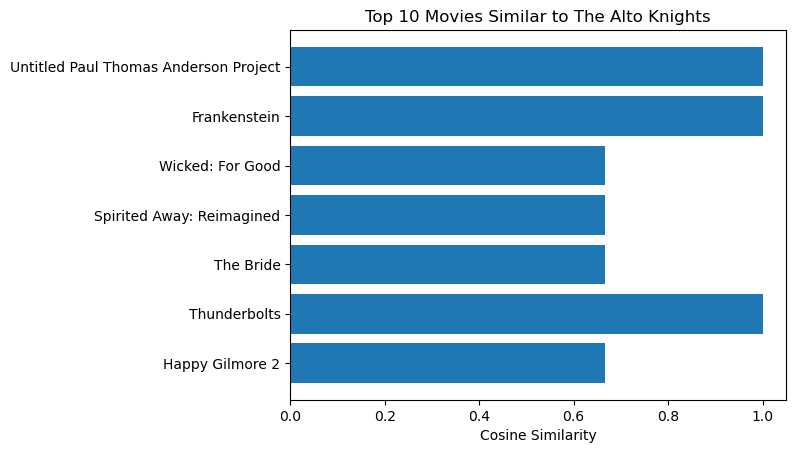

In [39]:

idx = movies[movies['Title'] == "The Alto Knights"].index[0]
sim_scores = list(enumerate(similarity_matrix[idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

scores = [score for i, score in sim_scores]
movies_list = [movies.loc[i, 'Title'] for i, score in sim_scores]

plt.barh(movies_list[::-1], scores[::-1])
plt.xlabel("Cosine Similarity")
plt.title("Top 10 Movies Similar to The Alto Knights")
plt.show()
